In [5]:
import torch

from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torchvision import transforms

if torch.cuda.is_available():
    print("CUDA is available. Training on GPU.")
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    print("Metal Performance Shaders (MPS) is available. Training on Apple Silicon GPU.")
    device = torch.device("mps")
else:
        print("CUDA and MPS are not available. Training on CPU.")
        device = torch.device("cpu")



transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = MNIST('~/data', train=True, download=True, transform=transform)
data_loader = DataLoader(train_dataset,batch_size=128, shuffle=True)

Metal Performance Shaders (MPS) is available. Training on Apple Silicon GPU.


# Conditional MLP GANs

In [26]:
import torch.nn as nn

num_class = 10
embedding_dim = 10
latent_dim = 100
img_shape = 28*28


class CGAN_gen(nn.Module):
    def __init__(self):
        super().__init__()

        self.labelembedding = nn.Embedding(num_class, embedding_dim)

        self.model = nn.Sequential(
            nn.Linear(latent_dim + embedding_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, img_shape),
            nn.Tanh()

        )
    def forward(self, noise, labels):
        c = self.labelembedding(labels)
        x = torch.cat([noise, c], 1)
        img = self.model(x)
        return img

class CGAN_disc(nn.Module):
    def __init__(self):
        super().__init__()

        self.labelembedding = nn.Embedding(num_class, embedding_dim)

        self.model = nn.Sequential(
            nn.Linear(img_shape + embedding_dim, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, img, labels):
        c = self.labelembedding(labels)
        x = torch.cat([img, c], 1)
        validity = self.model(x)
        return validity
    
generator = CGAN_gen().to(device)
discriminator = CGAN_disc().to(device)

In [27]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

vanilla_gen_params = count_parameters(generator)
vanilla_disc_params = count_parameters(discriminator)

print(f"Vanilla Generator Parameters: {vanilla_gen_params:,}")
print(f"Vanilla Discriminator Parameters: {vanilla_disc_params:,}")



Vanilla Generator Parameters: 1,489,012
Vanilla Discriminator Parameters: 1,470,565


In [7]:
import torch.optim as optim

d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002)
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)
loss = nn.BCELoss()

In [8]:
def noise(batch_size):
    n = torch.randn(batch_size, 100)
    return n.to(device)

In [9]:
def discriminator_train_step(real_data, real_labels, fake_data, fake_labels):
    vec_ones = torch.ones(len(real_data), 1).to(device)
    vec_zeros = torch.zeros(len(real_data), 1).to(device)

    discriminator.zero_grad()

    prediction_real = discriminator(real_data, real_labels)
    error_real = loss(prediction_real, vec_ones)
    error_real.backward()

    prediction_fake = discriminator(fake_data, fake_labels)
    error_fake = loss(prediction_fake, vec_zeros)
    error_fake.backward()

    d_optimizer.step()
    return error_real + error_fake

In [10]:
def generator_train_step(fake_data, fake_labels):
    vec_ones = torch.ones(len(fake_data), 1).to(device)

    g_optimizer.zero_grad()

    prediction = discriminator(fake_data, fake_labels)
    error = loss(prediction, vec_ones)
    error.backward()

    g_optimizer.step()
    return error

In [11]:

from torchvision.utils import make_grid
from torch_snippets import show

def plot_samples():
  z = torch.randn(64, 100).to(device)
  ordered_labels = torch.tensor([i % 10 for i in range(64)]).to(device)
  sample_images = generator(z, ordered_labels).data.cpu().view(64, 1, 28, 28)
  grid = make_grid(sample_images, nrow=8, normalize=True)
  show(grid.cpu().detach().permute(1,2,0), sz=5)

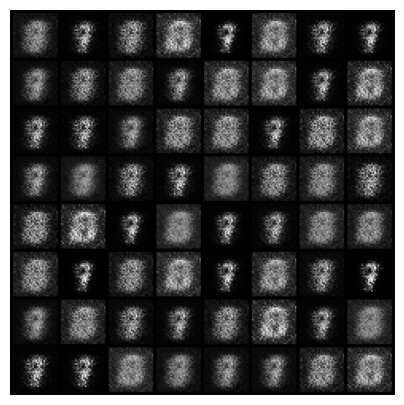

Epoch: 5


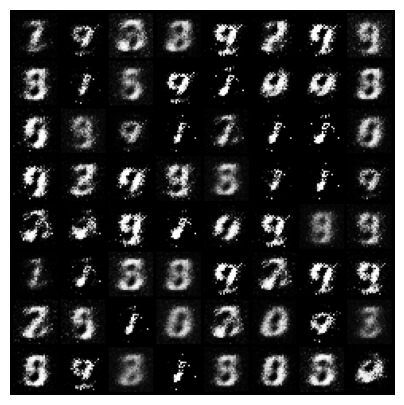

Epoch: 10


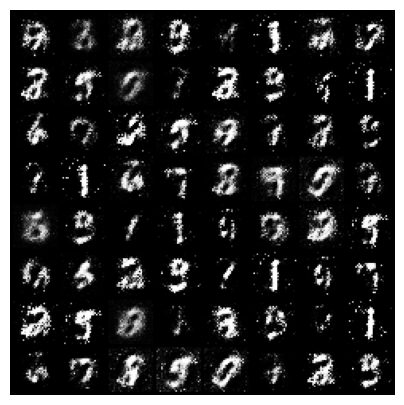

Epoch: 15


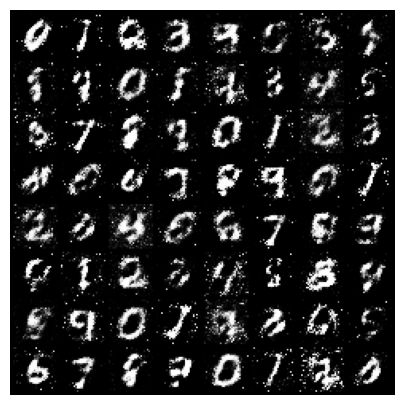

Epoch: 20


In [12]:
import numpy as np
#time
num_epochs = 20
for epoch in range(num_epochs):
    N = len(data_loader)
    for _, (images, labels) in enumerate(data_loader):
        n_images = len(images)
        
        real_data = images.view(n_images, -1).to(device)
        real_labels = labels.to(device)
        z = noise(n_images).to(device)
        fake_labels = torch.randint(0, num_class, (n_images,)).to(device)

        fake_data = generator(noise(n_images), fake_labels).to(device)
        # fake_data = fake_data
        d_loss = discriminator_train_step(real_data, real_labels, fake_data, fake_labels)

        fake_labels = torch.randint(0, num_class, (n_images,)).to(device)
        fake_data = generator(noise(n_images), fake_labels).to(device)
        g_loss = generator_train_step(fake_data, fake_labels)

    if (epoch+1) % 5 == 0:
        plot_samples()
        print(f"Epoch: {epoch+1}")

# Conditional Deep Convolutional GANs (DCGANs)

In [28]:
class DCGAN_gen(nn.Module):
    def __init__(self):
        super().__init__()

        self.labelembedding = nn.Embedding(num_class, embedding_dim)

        self.model = nn.Sequential(
            nn.ConvTranspose2d(110, 128, kernel_size=4, stride=1, padding=0),  # [batch, 128, 4, 4]
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3), 
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # [batch, 64, 8, 8]
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3), 
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    # [batch, 32, 16, 16]
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=3),     # [batch, 1, 28, 28]
            nn.Tanh()
        )
    def forward(self, noise, labels):
        c = self.labelembedding(labels)
        c = c.view(c.size(0), c.size(1), 1, 1)
        c = c.expand(-1, -1, noise.size(2), noise.size(3))
        x = torch.cat([noise, c], 1)
        img = self.model(x)
        return img

class DCGAN_disc(nn.Module):
    def __init__(self):
        super().__init__()

        self.labelembedding = nn.Embedding(num_class, embedding_dim)

        self.model = nn.Sequential(
            nn.Conv2d(1 + embedding_dim, 64, kernel_size=4, stride=2, padding=1), # 
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Conv2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3), 
            nn.Conv2d(32, 16, kernel_size=4, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Flatten(), 
            nn.Linear(16*6*6, 1),            
            nn.Sigmoid()
        )
    def forward(self, img, labels):
        c = self.labelembedding(labels)
        c = c.view(c.size(0), c.size(1), 1, 1)
        c = c.expand(-1, -1, img.size(2), img.size(3))
        x = torch.cat([img, c], 1)
        validity = self.model(x)
        return validity

generator = DCGAN_gen().to(device)
discriminator = DCGAN_disc().to(device)

In [29]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

vanilla_gen_params = count_parameters(generator)
vanilla_disc_params = count_parameters(discriminator)

print(f"Vanilla Generator Parameters: {vanilla_gen_params:,}")
print(f"Vanilla Discriminator Parameters: {vanilla_disc_params:,}")



Vanilla Generator Parameters: 389,957
Vanilla Discriminator Parameters: 53,013


In [14]:
import torch.optim as optim 

d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002)
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)
loss = nn.BCELoss()

In [15]:
def noise_2d(batch_size):
    n = torch.randn(batch_size, 100, 1, 1)
    return n.to(device)

In [16]:
def discriminator_train_step(real_data, real_labels, fake_data, fake_labels):
    vec_ones = torch.ones(len(real_data), 1).to(device)
    vec_zeros = torch.zeros(len(real_data), 1).to(device)

    discriminator.zero_grad()

    prediction_real = discriminator(real_data, real_labels)
    error_real = loss(prediction_real, vec_ones)
    error_real.backward()

    prediction_fake = discriminator(fake_data.detach(), fake_labels)
    error_fake = loss(prediction_fake, vec_zeros)
    error_fake.backward()

    d_optimizer.step()
    return error_real + error_fake

In [17]:
def generator_train_step(fake_data, fake_labels):
    vec_ones = torch.ones(len(fake_data), 1).to(device)

    g_optimizer.zero_grad()

    prediction = discriminator(fake_data, fake_labels)
    error = loss(prediction, vec_ones)
    error.backward()

    g_optimizer.step()
    return error

In [18]:
from torchvision.utils import make_grid
from torch_snippets import show
import matplotlib.pyplot as plt
import os

def plot_samples_2d():
    z = torch.randn(64, 100, 1, 1).to(device)
    ordered_labels = torch.tensor([i % 10 for i in range(64)]).to(device)
    sample_images = generator(z, ordered_labels).data.cpu()
    grid = make_grid(sample_images, nrow=8, normalize=True)
    show(grid.cpu().detach().permute(1,2,0), sz=5)
    os.makedirs("./Outputs", exist_ok=True)
    
    

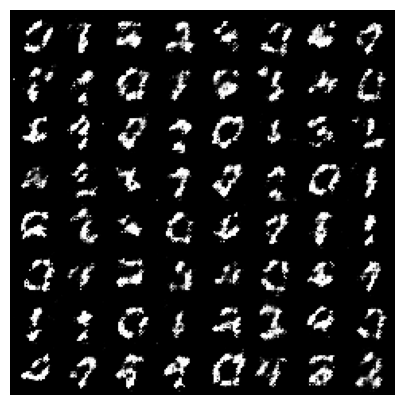

Epoch: 5


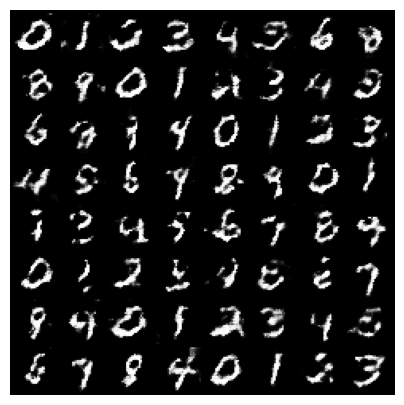

Epoch: 10


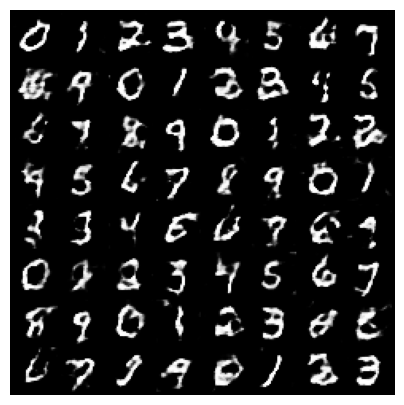

Epoch: 15


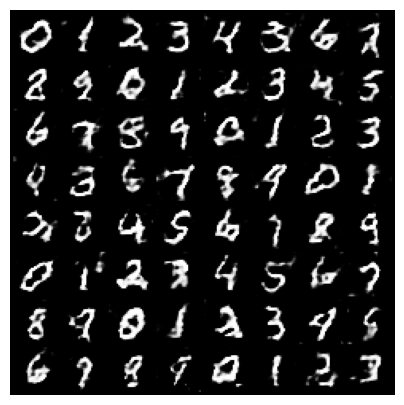

Epoch: 20


In [19]:
import numpy as np 

num_epochs = 20 
for epoch in range(num_epochs):
    N = len(data_loader) 
    for _, (images, labels) in enumerate(data_loader):
        n_images = len(images)
        
        real_data = images.view(n_images, 1, 28, 28).to(device)
        real_labels = labels.to(device)
        z = noise_2d(n_images).to(device)
        fake_labels = torch.randint(0, num_class, (n_images,)).to(device)

        fake_data = generator(noise_2d(n_images), fake_labels).to(device)
        
        # fake_data = fake_data
        d_loss = discriminator_train_step(real_data, real_labels, fake_data, fake_labels)

        fake_labels = torch.randint(0, num_class, (n_images,)).to(device)
        fake_data = generator(noise_2d(n_images), fake_labels).to(device)
        g_loss = generator_train_step(fake_data, fake_labels)

    if (epoch+1) % 5 == 0:
        plot_samples_2d()
        print(f"Epoch: {epoch+1}")

# MLP Classifier

In [ ]:
import torch.nn as nn
import torch.nn.functional as F



class MNIST_Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize
classifier = MNIST_Classifier().to(device)

In [21]:
import torch.optim as optim

criterion_cls = nn.CrossEntropyLoss()
optimizer_cls = optim.Adam(classifier.parameters(), lr=0.001)

num_classifier_epochs = 5 #shouldnt need too many for this

for epoch in range(num_classifier_epochs):
    classifier.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (images, labels) in enumerate(data_loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer_cls.zero_grad()
        outputs = classifier(images)
        loss = criterion_cls(outputs, labels)
        
        loss.backward()
        optimizer_cls.step()
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / len(data_loader)
    epoch_acc = 100 * correct / total
    
    print(f"Classifier Epoch [{epoch+1}/{num_classifier_epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

Starting Classifier Training...
Classifier Epoch [1/5] | Loss: 0.3052 | Accuracy: 91.03%
Classifier Epoch [2/5] | Loss: 0.0683 | Accuracy: 97.97%
Classifier Epoch [3/5] | Loss: 0.0481 | Accuracy: 98.55%
Classifier Epoch [4/5] | Loss: 0.0376 | Accuracy: 98.83%
Classifier Epoch [5/5] | Loss: 0.0302 | Accuracy: 99.06%


In [ ]:
def evaluate_cgan_accuracy(generator, classifier, samples_per_class=100):
    generator.eval()
    classifier.eval()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for digit in range(10):
            labels = torch.full((samples_per_class,), digit, dtype=torch.long).to(device)
            z = torch.randn(samples_per_class, 100).to(device)
            fake_images = generator(z, labels)
            fake_images = fake_images.view(-1, 1, 28, 28)
            outputs = classifier(fake_images)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            class_acc = 100 * (predicted == labels).sum().item() / labels.size(0)
            print(f"Accuracy for digit {digit}: {class_acc:.2f}%")

    overall_accuracy = 100 * correct / total
    print(f"\nOverall CGAN Generation Accuracy: {overall_accuracy:.2f}%")
    return overall_accuracy

def evaluate_dcgan_accuracy(generator, classifier, samples_per_class=100):
    generator.eval()
    classifier.eval()
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for digit in range(10):
            labels = torch.full((samples_per_class,), digit, dtype=torch.long).to(device)
            z = torch.randn(samples_per_class, 100, 1, 1).to(device)
            fake_images = generator(z, labels)
            outputs = classifier(fake_images)
            _, predicted = torch.max(outputs.data, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            class_acc = 100 * (predicted == labels).sum().item() / labels.size(0)
            print(f"Accuracy for digit {digit}: {class_acc:.2f}%")

    overall_accuracy = 100 * correct / total
    print(f"\nOverall DCGAN Generation Accuracy: {overall_accuracy:.2f}%\n")
    return overall_accuracy

vanilla_generator = CGAN_gen().to(device)
dcgan_generator = DCGAN_gen().to(device)


cgan_accuracy = evaluate_cgan_accuracy(vanilla_generator, classifier)
dcgan_accuracy = evaluate_dcgan_accuracy(dcgan_generator, classifier)

Accuracy for digit 0: 0.00%
Accuracy for digit 1: 0.00%
Accuracy for digit 2: 0.00%
Accuracy for digit 3: 0.00%
Accuracy for digit 4: 0.00%
Accuracy for digit 5: 12.00%
Accuracy for digit 6: 28.00%
Accuracy for digit 7: 0.00%
Accuracy for digit 8: 24.00%
Accuracy for digit 9: 16.00%

Overall CGAN Generation Accuracy: 8.00%
Accuracy for digit 0: 0.00%
Accuracy for digit 1: 100.00%
Accuracy for digit 2: 0.00%
Accuracy for digit 3: 0.00%
Accuracy for digit 4: 0.00%
Accuracy for digit 5: 0.00%
Accuracy for digit 6: 0.00%
Accuracy for digit 7: 0.00%
Accuracy for digit 8: 0.00%
Accuracy for digit 9: 0.00%

Overall DCGAN Generation Accuracy: 10.00%
